In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import urllib.request
import requests
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from functions import apply_correlation_to_df, normalize_column, z_score_column

# set the themes
sns.set_theme(style="darkgrid")
%matplotlib inline


## Setup

Import libraries and configure plot styling. We use `seaborn` for statistical graphics with a clean whitegrid theme, and `autoreload` to hot-reload helper functions from [functions.py](functions.py) during development.

# Carbon Emissions and Economic Development: A Visual Analysis

The central question driving this analysis is whether economic growth necessarily comes at the cost of rising carbon emissions - or whether countries can **decouple** the two. This is one of the most consequential questions in climate policy: if decoupling is possible, it suggests that prosperity and sustainability are not mutually exclusive.

To investigate this, we combine two authoritative datasets:

1. **CO2 Emissions** (Our World in Data, 1750–2024) - historical emissions by country, measured in millions of tonnes
2. **GDP** (World Bank, 1960–2024) - economic output in current USD
3. **Electricity** (Our World in Data, 2000-2024) - Share of electricity production methods of the countries

By normalizing both metrics to per-capita values and computing Pearson correlations over time, we can classify countries along a spectrum: from those where growth and emissions move in lockstep (strong coupling) to those where GDP continues to rise while emissions fall (decoupling). We then ask whether this pattern is systematic - do high-income countries decouple more than low-income ones?

## CO2 Emissions Data

We load the Our World in Data CO2 dataset, which contains 79 columns spanning energy mix, land use, and emissions breakdowns. For this analysis we reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2` (total production-based CO2 emissions in millions of tonnes).

Two important filtering steps:
- **Drop rows without `iso_code`**: The dataset includes aggregate entities like "Africa", "OECD", and "World" that lack ISO country codes. Removing these ensures we work exclusively with individual nation-states.
- **Filter to post-1960**: GDP data from the World Bank only begins in 1960, so we align the time range to enable a clean merge later.

In [4]:
co2_df = pd.read_csv('data/co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
co2_df = co2_df[selected_columns].copy()

# remove entries with no iso code(Continents and other groups)
co2_df = co2_df[co2_df['iso_code'].notna() & (co2_df['iso_code'].str.strip() != '')]
co2_df = co2_df[co2_df['year'] > 1960]

co2_df


,country,year,iso_code,population,co2
211,Afghanistan,1961,AFG,9214082.0,0.491
212,Afghanistan,1962,AFG,9404410.0,0.689
213,Afghanistan,1963,AFG,9604491.0,0.707
214,Afghanistan,1964,AFG,9814317.0,0.839
215,Afghanistan,1965,AFG,10036003.0,1.007
...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,8.491
50407,Zimbabwe,2021,ZWE,15797220.0,10.223
50408,Zimbabwe,2022,ZWE,16069061.0,12.232
50409,Zimbabwe,2023,ZWE,16340829.0,13.443


## GDP Data

The World Bank GDP dataset arrives in **wide format** - one column per year (1960, 1961, ..., 2024). This is convenient for spreadsheet viewing but incompatible with tidy-data principles needed for plotting and merging. We use `pd.melt()` to reshape it into long format with one row per country-year observation.

Key steps:
- **Melt** year columns into `year` (int) and `gdp` (numeric) columns
- **Rename** `Country Code` to `iso_code` to create a shared merge key with the CO2 dataset
- **Drop missing GDP values** - not all countries have GDP records for every year, particularly in earlier decades or for newly independent states

In [5]:
# load GDP data
gdp_df = pd.read_csv('data/gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)

# convert year to integer and gdp to numeric
gdp_df['year'] = gdp_df['year'].astype(int)
gdp_df['gdp'] = pd.to_numeric(gdp_df['gdp'], errors='coerce')

# rename Country Code to iso_code for merging
gdp_df = gdp_df.rename(columns={'Country Code': 'iso_code'})

# keep only the columns we need
gdp_df = gdp_df[['iso_code', 'year', 'gdp']]

# remove rows with missing GDP values
gdp_df = gdp_df.dropna(subset=['gdp'])

gdp_df

,iso_code,year,gdp
1,AFE,1960,2.420569e+10
3,AFW,1960,1.190481e+10
9,ARG,1960,1.586547e+10
13,AUS,1960,1.863568e+10
14,AUT,1960,6.624086e+09
...,...,...,...
17284,WSM,2024,1.175750e+09
17285,XKX,2024,1.119725e+10
17287,ZAF,2024,4.011450e+11
17288,ZMB,2024,2.530319e+10


## Merging the Datasets

We perform a **left join** of GDP onto the CO2 dataframe using `iso_code` and `year` as composite keys. A left join preserves every CO2 record and attaches GDP where available - countries or years without World Bank GDP data simply receive NaN. This is preferable to an inner join because it avoids silently discarding emission records that are still valuable for other analyses.

### Missing Data Heatmap

Before proceeding, we visualize data completeness. The heatmap below shows each variable as a column and each record as a row, with bright cells indicating missing values. This diagnostic is important because it reveals whether missingness is **random** or **systematic** - for instance, GDP data may be consistently absent for certain countries or time periods, which would bias any analysis that silently drops incomplete rows.

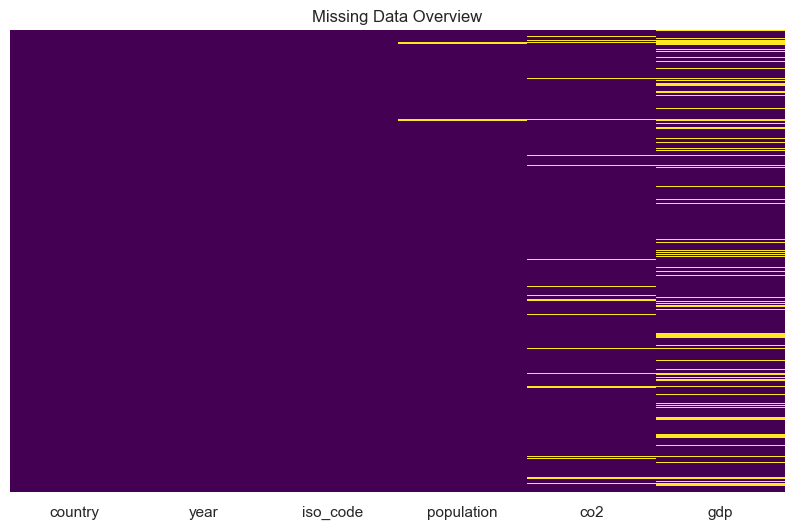

In [6]:
# merge the datasets on iso_code and year, append gdp to the right
base_df = co2_df.merge(
    gdp_df,
    on=['iso_code', 'year'],
    how='left',
    suffixes=('_co2', '_gdp')
)

# show the dataframe as heatmap to see where we have missing values
plt.figure(figsize=(10, 6))
sns.heatmap(base_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Overview")
plt.show()


## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people, not necessarily because their economies or industries are more carbon-intensive on a per-person basis. Dividing by population yields **per-capita** values that enable fairer cross-country comparisons: how much does the average citizen emit, and how wealthy is the average citizen?

We use `np.divide` with a `where` guard to handle zero or missing population entries without raising division errors.

In [7]:
# extract as numpy arrays
pop_arr = base_df['population'].values
co2_arr = base_df['co2'].values
gdp_arr = base_df['gdp']

# vectorized division, check for NaN or invalid values and only calculate the correct values
base_df['co2_per_capita'] = np.divide(co2_arr, pop_arr, out = np.zeros_like(co2_arr), where = pop_arr > 0)
base_df['gdp_per_capita'] = np.divide(gdp_arr, pop_arr, out = np.zeros_like(gdp_arr), where = pop_arr > 0)


# Correlation Analysis

To quantify the relationship between economic growth and carbon emissions, we compute the **Pearson correlation coefficient** (r) between GDP per capita and CO2 per capita for each country across its full available time series.

- **r close to +1** indicates strong coupling - GDP and emissions rise together, typical of industrializing economies reliant on fossil fuels.
- **r close to 0** suggests no linear relationship - the two metrics move independently.
- **r < 0** indicates **decoupling** - GDP continues to grow while emissions decline, often driven by transitions to services-based economies, renewable energy adoption, or efficiency gains.

A minimum of 5 data points per country is required to compute a meaningful correlation; countries with fewer observations are excluded. It is worth noting that Pearson r captures only *linear* association - a country that industrialized heavily, peaked, and then decoupled will show a moderate positive r despite having a clear structural break in its emission trajectory.

In [8]:
base_df['Correlation'] = apply_correlation_to_df(base_df)

base_df

C:\Users\frank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\frank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,5.328800e-08,NaN,0.915700
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,7.326350e-08,NaN,0.915700
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,7.361140e-08,NaN,0.915700
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,8.548735e-08,NaN,0.915700
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,1.003388e-07,NaN,0.915700
...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,5.468578e-07,2059.674586,-0.507579
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,6.471392e-07,2613.603766,-0.507579
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,7.612144e-07,2536.399713,-0.507579
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,8.226633e-07,2195.223980,-0.507579


## Country-Level Analysis: GDP vs CO2 Over Time

The dual-axis line plot below overlays GDP per capita and CO2 per capita for a selected country on a shared timeline. Two independent y-axes are necessary because the two metrics operate on vastly different scales (dollars vs. tonnes), but their *temporal trajectories* are directly comparable.

This visualization directly tests the core question of the analysis:
- **Parallel upward trends** indicate that the economy remains carbon-intensive - growth is fuelled by fossil energy.
- **Diverging trends** (GDP rising, CO2 flattening or declining) are evidence of **decoupling**, often driven by shifts toward service economies, renewable energy, or industrial efficiency.

The annotated Pearson r value provides a single-number summary of the visual relationship.

In [9]:
# random choice of countries to be compares
country = 'Finland'
my_selection = [country]

# create a dataframe just for those countries
df_selected = base_df[base_df['country'].isin(my_selection)]

df_selected


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation
4480,Finland,1961,FIN,4460998.0,14.922,5.984434e+09,0.000003,1341.501111,0.151857
4481,Finland,1962,FIN,4491739.0,16.794,6.407796e+09,0.000004,1426.573548,0.151857
4482,Finland,1963,FIN,4523897.0,19.336,6.958917e+09,0.000004,1538.257071,0.151857
4483,Finland,1964,FIN,4549092.0,22.831,7.848988e+09,0.000005,1725.396583,0.151857
4484,Finland,1965,FIN,4564150.0,25.300,8.680394e+09,0.000006,1901.864277,0.151857
...,...,...,...,...,...,...,...,...,...
4539,Finland,2020,FIN,5529616.0,37.720,2.700003e+11,0.000007,48828.040068,0.151857
4540,Finland,2021,FIN,5541069.0,37.820,2.942232e+11,0.000007,53098.636833,0.151857
4541,Finland,2022,FIN,5569300.0,36.337,2.802531e+11,0.000007,50321.063564,0.151857
4542,Finland,2023,FIN,5601185.0,31.799,2.950220e+11,0.000006,52671.351234,0.151857


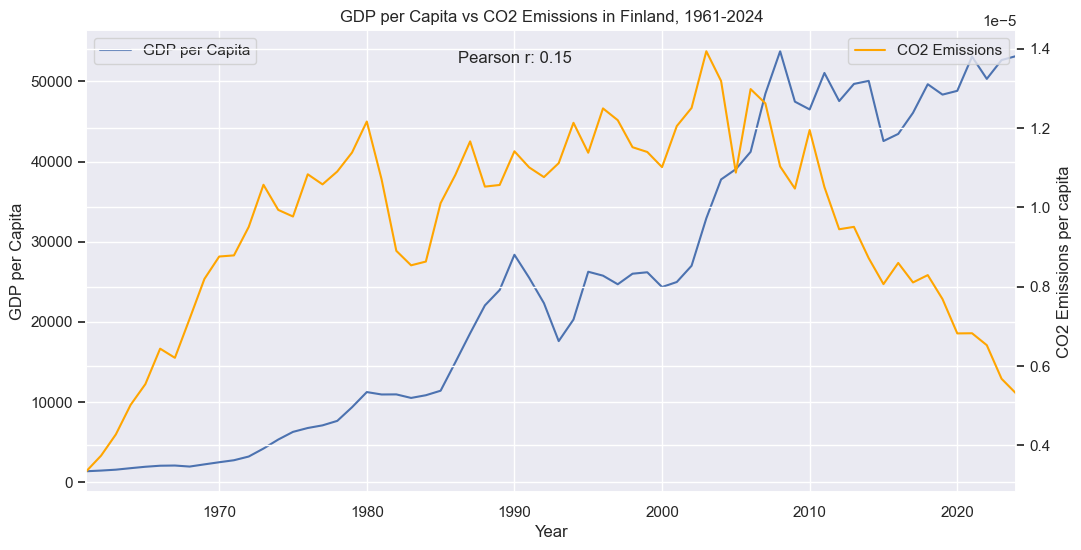

In [10]:
# create a figure and axes

# first ax is for gdp per capita
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_selected['year'], df_selected['gdp_per_capita'], label='GDP per Capita')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP per Capita')
ax1.legend(loc='upper left')

# second ax is for co2 per capita, just a twin of the first ax
ax2 = ax1.twinx()
ax2.plot(df_selected['year'], df_selected['co2_per_capita'], label='CO2 Emissions', color='orange')
ax2.set_ylabel('CO2 Emissions per capita')
ax2.legend(loc='upper right')

# annotate
ax1.annotate(f'Pearson r: {df_selected['Correlation'].iloc[-1]:.2f}', xy=(0.4, 0.93), xycoords='axes fraction', fontsize=12)

# set the x axis to the min and max of the valid years, as some countries have missing data
valid_years = df_selected.dropna(subset=['gdp_per_capita', 'co2_per_capita'])['year']

if not valid_years.empty:
    min_year = valid_years.min()
    max_year = valid_years.max()
    ax1.set_xlim(min_year, max_year)

# show the plot
plt.title(f'GDP per Capita vs CO2 Emissions in {country}, {min_year}-{max_year}')
plt.show()

C:\Users\frank\AppData\Local\Temp\ipykernel_20160\19515176.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=ax1, x='year', y='co2_per_capita', data=base_df, palette='magma')
C:\Users\frank\AppData\Local\Temp\ipykernel_20160\19515176.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=ax2, x='year', y='gdp_per_capita', data=base_df, palette='magma')


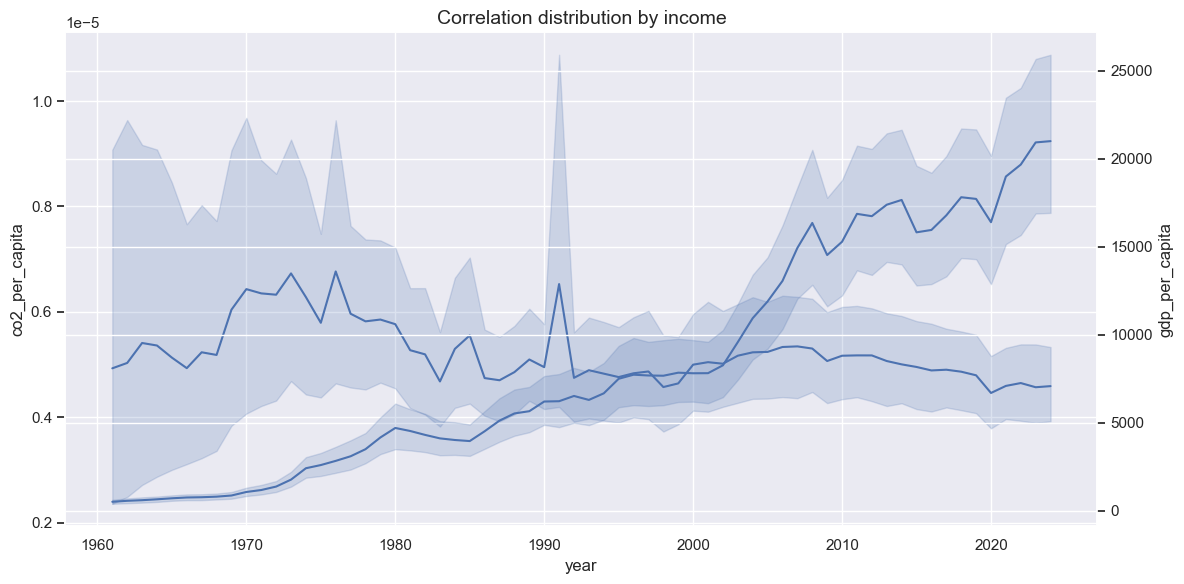

In [11]:
fig, (ax1) = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
# create a violinplot by income
sns.lineplot(ax=ax1, x='year', y='co2_per_capita', data=base_df, palette='magma')
ax1.set_title('Correlation distribution by income', fontsize=14)

sns.lineplot(ax=ax2, x='year', y='gdp_per_capita', data=base_df, palette='magma')

plt.tight_layout()
plt.show()

## Income Group Classification

To move beyond individual country case studies, we classify each observation by **income group** using the World Bank's Gross National Income (GNI) thresholds:

| Group | GNI per capita (current USD) |
|---|---|
| Low | $\leq$ 1,145 |
| Lower-Middle | 1,146 – 4,515 |
| Upper-Middle | 4,516 – 14,005 |
| High | $>$ 14,005 |

Source: [World Bank Country Classification (FY2025)](https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups)

This allows us to ask a structural question: do emission trajectories differ systematically between rich and poor countries? We scrape current GNI per capita figures from Wikipedia and merge them onto our dataset, then apply `pd.cut` to assign income brackets based on GDP per capita as a proxy.

In [12]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GNI_(nominal)_per_capita'

tables = pd.read_html(url, storage_options={'User-Agent': 'Mozilla/5.0'})

# table 1 contains the GNI per capita data
gni_df = tables[1]

dict = {
    'GNI per capita (US$)[1][3]': 'gni_per_capita'
}

gni_df = gni_df.rename(columns=dict)

gni_df



,Unnamed: 0,Country,gni_per_capita,Year
0,NaN,High Income Economies,NaN,2024
1,–,Bermuda (UK),145150.0,2024
2,1,Liechtenstein,116600.0,2009
3,2,Norway,98170.0,2024
4,3,Switzerland,95220.0,2024
...,...,...,...,...
207,187,Madagascar,510.0,2024
208,188,Yemen,470.0,2024
209,189,Afghanistan,370.0,2023
210,190,South Sudan,350.0,2024


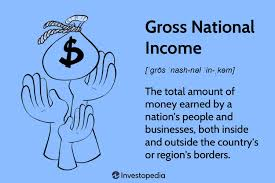

In [13]:
# normalize 
gni_df['country_clean'] = normalize_column(gni_df, 'Country')
base_df['country_clean'] = normalize_column(base_df, 'country')

# left merge
main_df = pd.merge(base_df, gni_df[['country_clean', 'gni_per_capita']], 
                     on='country_clean', how='left')

# definition of bins and labels
# https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups
bins = [0, 1145, 4515, 14005, np.inf]
labels = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']

main_df['income_group'] = pd.cut(main_df['gdp_per_capita'], bins=bins, labels=labels)

main_df


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation,country_clean,gni_per_capita,income_group
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,5.328800e-08,NaN,0.915700,afghanistan,370.0,NaN
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,7.326350e-08,NaN,0.915700,afghanistan,370.0,NaN
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,7.361140e-08,NaN,0.915700,afghanistan,370.0,NaN
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,8.548735e-08,NaN,0.915700,afghanistan,370.0,NaN
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,1.003388e-07,NaN,0.915700,afghanistan,370.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,5.468578e-07,2059.674586,-0.507579,zimbabwe,2260.0,Lower-Middle
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,6.471392e-07,2613.603766,-0.507579,zimbabwe,2260.0,Lower-Middle
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,7.612144e-07,2536.399713,-0.507579,zimbabwe,2260.0,Lower-Middle
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,8.226633e-07,2195.223980,-0.507579,zimbabwe,2260.0,Lower-Middle


### Distribution of Income Groups (2024)

Before comparing emissions across income groups, we first check how many countries fall into each bracket in 2024. This serves as a **sanity check** — if one group is heavily overrepresented or nearly empty, later comparisons would be unreliable due to uneven sample sizes. The countplot also reflects the current structure of global economic inequality.

<Axes: xlabel='income_group', ylabel='count'>

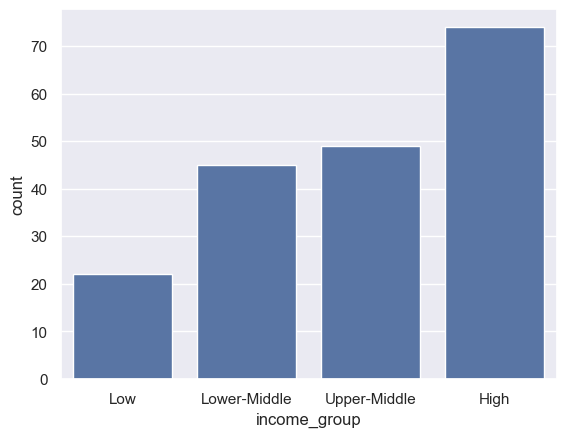

In [14]:
df_2024 = main_df[main_df['year'] == 2024]
sns.countplot(data=df_2024, x = 'income_group')


C:\Users\frank\AppData\Local\Temp\ipykernel_20160\1478330494.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(ax=ax2, x='Correlation', y='country', data=top_decouplers, palette='magma', legend=False)


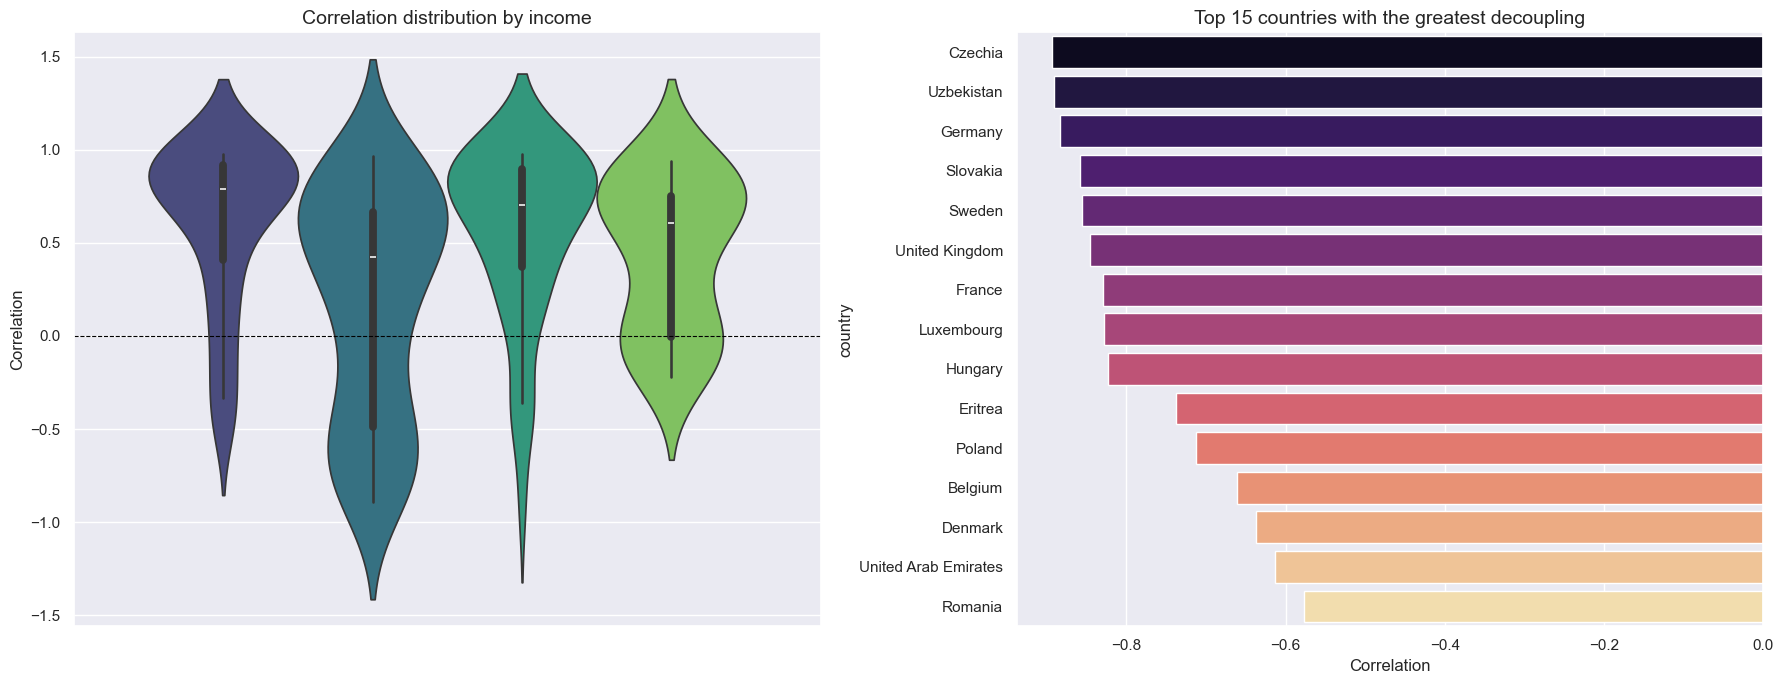

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# create a violinplot by income
sns.violinplot(ax=ax1, hue='income_group', y='Correlation', data=df_2024, palette='viridis', legend=False)
ax1.set_title('Correlation distribution by income', fontsize=14)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

# show the top decouplers
top_decouplers = df_2024.nsmallest(15, 'Correlation')

# TODO: Find out why hue screws up the visualisation
# Keep error for now
barplot = sns.barplot(ax=ax2, x='Correlation', y='country', data=top_decouplers, palette='magma', legend=False)

ax2.set_title('Top 15 countries with the greatest decoupling', fontsize=14)

plt.tight_layout()
plt.show()

### Interpreting the Results

The violin plot reveals how the GDP–CO2 correlation distributes within each income bracket. High-income countries show a wider spread with more negative correlations, suggesting that decoupling is more prevalent — and more varied — among wealthy nations. Lower-income groups cluster tightly around positive correlations, indicating that economic growth and emissions still move in tandem.

The bar chart of the top 15 decouplers (most negative Pearson r) surfaces some initially surprising entries — Uzbekistan and Czechia rank highly. However, this is consistent with the post-Soviet economic transition: many former Eastern Bloc countries experienced simultaneous GDP growth and emissions decline as they dismantled inefficient heavy industry inherited from the Soviet era and transitioned toward market economies with lighter industrial footprints.

The presence of the UAE among the top decouplers likely reflects its aggressive economic diversification away from oil dependency toward tourism, finance, and technology — sectors that generate GDP without proportional CO2 increases.

### Historical Emission Paths by Income Group

The FacetGrid below plots per-capita CO2 over time, split into separate panels by income group. Each panel uses `sns.lineplot`, which computes the **mean** across all countries in that bracket along with a 95% confidence interval (shaded band).

We use separate panels rather than overlaying all four groups on a single axis for two reasons:
1. High-income countries emit orders of magnitude more per capita than low-income ones, which would compress the lower groups into flat lines at the bottom of a shared y-axis.
2. `sharey=False` gives each panel its own y-scale, allowing the internal trends within each group to be clearly visible.

**Key patterns to look for:**
- **High income**: A rise-then-decline trajectory — emissions peaked around the 1970s–2000s and have since been falling, consistent with deindustrialization, fuel switching, and policy intervention.
- **Upper-Middle**: Rapid growth phase, potentially still climbing as industrialization continues (driven heavily by China's trajectory in this bracket).
- **Lower-Middle / Low**: Flat, low emissions — these countries have contributed minimally to cumulative global CO2 despite housing large shares of the world's population.

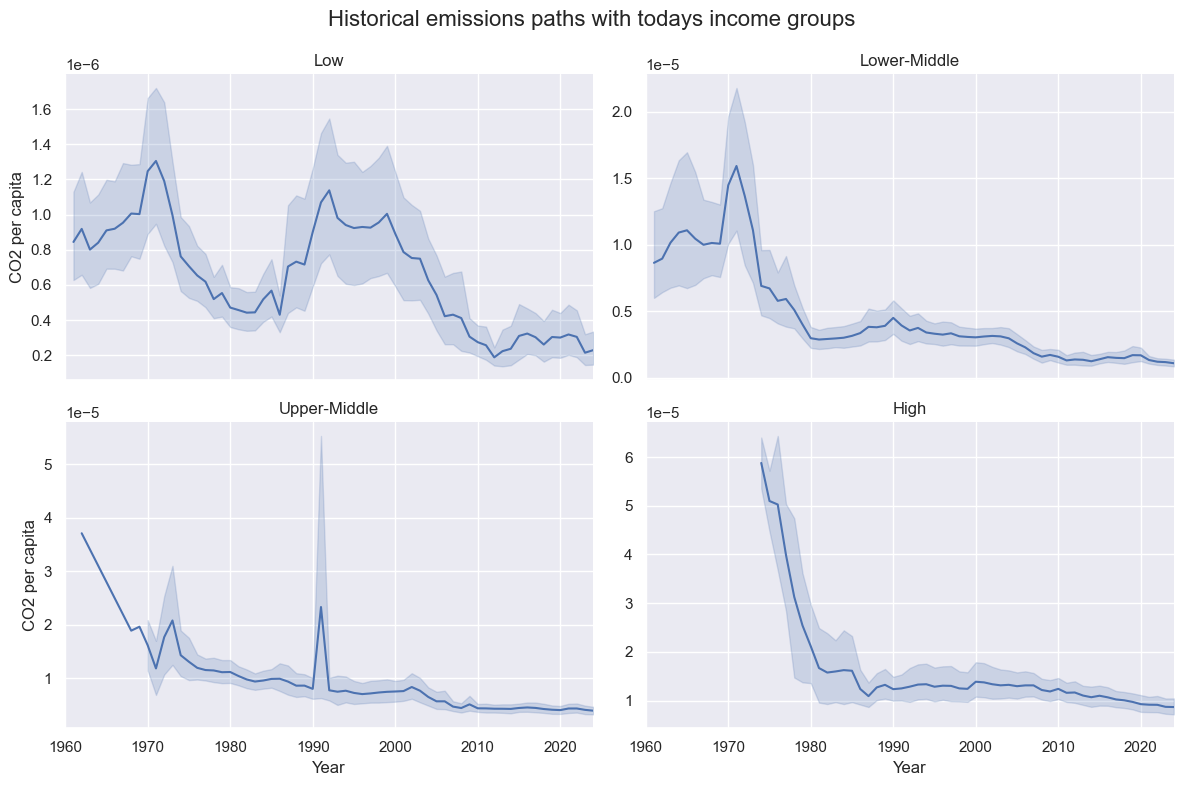

In [16]:
# compare historical emissions paths
g = sns.FacetGrid(main_df, col="income_group", col_wrap=2, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "year", "co2_per_capita")

g.set(xlim=(1960, 2024))
g.set_axis_labels("Year", "CO2 per capita")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Historical emissions paths with todays income groups", fontsize=16)
plt.show()

### Observations

The faceted emission trajectories confirm a clear structural divide:

- **High-income countries** show the classic inverted-U pattern (an Environmental Kuznets Curve shape) — emissions rose during industrialization, peaked, and have since declined as economies shifted toward services and cleaner energy.
- **Upper-middle-income countries** display a notable spike around 1990, which can be attributed to several concurrent forces: China's rapid industrialization, the collapse of the Soviet Union (which reshuffled country classifications), and the outsourcing of manufacturing from high-income nations to countries in this bracket.
- **Lower-income groups** remain nearly flat throughout the entire period, underscoring the stark global inequality in both emissions responsibility and economic development.

This pattern supports the hypothesis that decoupling is largely a phenomenon of already-wealthy nations — those that have already passed through their most carbon-intensive growth phase.

In [17]:
# extract as numpy arrays
co2_arr = main_df['co2'].values
gdp_arr = np.divide(main_df['gdp'], 1000000)

# vectorized division, check for NaN or invalid values and only calculate the correct values
main_df['co2_per_gdp'] = np.divide(co2_arr, gdp_arr, out = np.zeros_like(co2_arr), where = co2_arr > 0)

main_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation,country_clean,gni_per_capita,income_group,co2_per_gdp
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,5.328800e-08,NaN,0.915700,afghanistan,370.0,NaN,NaN
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,7.326350e-08,NaN,0.915700,afghanistan,370.0,NaN,NaN
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,7.361140e-08,NaN,0.915700,afghanistan,370.0,NaN,NaN
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,8.548735e-08,NaN,0.915700,afghanistan,370.0,NaN,NaN
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,1.003388e-07,NaN,0.915700,afghanistan,370.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,5.468578e-07,2059.674586,-0.507579,zimbabwe,2260.0,Lower-Middle,0.000266
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,6.471392e-07,2613.603766,-0.507579,zimbabwe,2260.0,Lower-Middle,0.000248
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,7.612144e-07,2536.399713,-0.507579,zimbabwe,2260.0,Lower-Middle,0.000300
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,8.226633e-07,2195.223980,-0.507579,zimbabwe,2260.0,Lower-Middle,0.000375


# CO2 per $1 Million GDP analysis

CO2 per GDP is an indicator as to how efficient/inefficient an economy is in terms of emmisions. Typically we can observe a trend downwards, as technological advancements make economies more efficient, while emmiting less CO2. 

We might also assume, that richer, high income countries are often the most efficient, due to the abundance of technological advancements and investions into greener production. 

Due to countries like China, India or former Soviet States being in the upper-middle category, we can also assume them to be the the most inefficient economies.

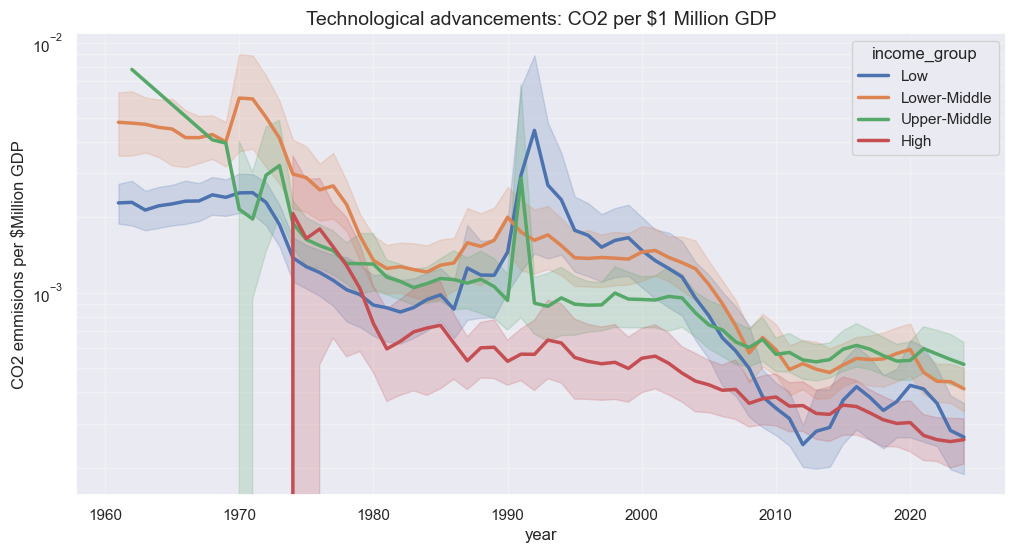

In [18]:
# create a figure 
plt.figure(figsize=(12, 6))

sns.lineplot(data=main_df, x='year', y='co2_per_gdp', hue='income_group', linewidth=2.5)

plt.yscale('log')
plt.title('Technological advancements: CO2 per $1 Million GDP', fontsize=14)
plt.ylabel('CO2 emmisions per $Million GDP')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

C:\Users\frank\AppData\Local\Temp\ipykernel_20160\639719628.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_2024['co2_per_gdp'] = main_df[main_df['year'] == 2024][main_df['population'] > min_pop]['co2_per_gdp']
C:\Users\frank\AppData\Local\Temp\ipykernel_20160\639719628.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax1, x='co2_per_gdp', y='country', data=most_efficient, palette='viridis')
C:\Users\frank\AppData\Local\Temp\ipykernel_20160\639719628.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(ax=ax2, x='co2_per_gdp', y='country', data=least_efficient, palette='magma', legend=False)


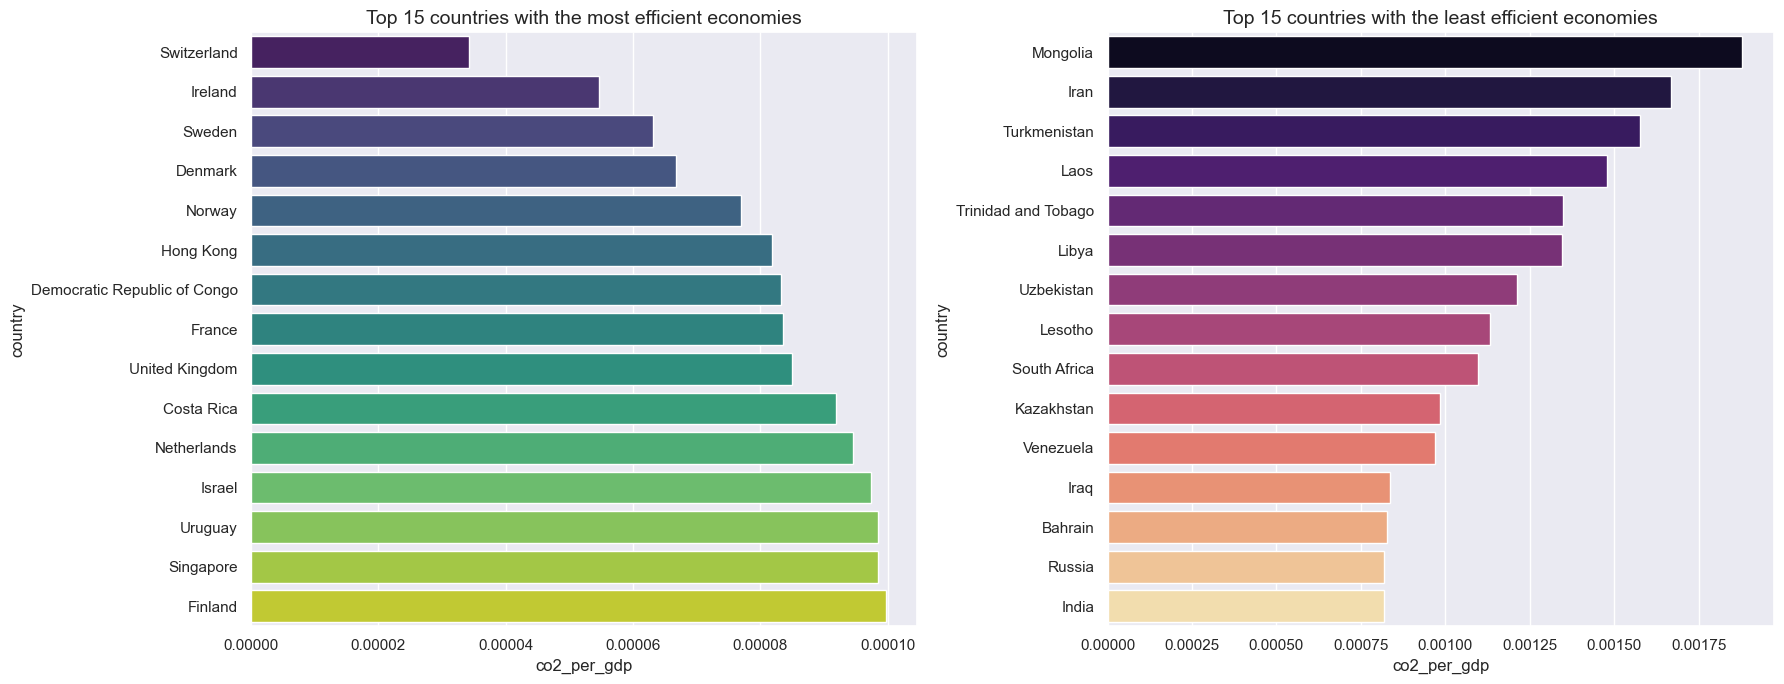

In [19]:
# cut the smaller economies like the Vatican off based on overall population
min_pop = 1000000

df_2024['co2_per_gdp'] = main_df[main_df['year'] == 2024][main_df['population'] > min_pop]['co2_per_gdp']
base_df['co2_per_gdp'] = main_df['co2_per_gdp']

most_efficient = df_2024.nsmallest(15, 'co2_per_gdp')
least_efficient = df_2024.nlargest(15, 'co2_per_gdp')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=ax1, x='co2_per_gdp', y='country', data=most_efficient, palette='viridis')
ax1.set_title('Top 15 countries with the most efficient economies', fontsize=14)

# TODO: Find out why hue screws up the visualisation
# Keep error for now
barplot = sns.barplot(ax=ax2, x='co2_per_gdp', y='country', data=least_efficient, palette='magma', legend=False)

ax2.set_title('Top 15 countries with the least efficient economies', fontsize=14)

plt.tight_layout()
plt.show()


# Evaluating the efficiency of economies

### Most efficient economies

Countries like San Marino, Vatican, Monaco or the Christmas Island are known for having little to no industry and their economy mainly consists of services. 

The other countries produce roughly 1:100 as much as Mongolia, the top of the list. 

### Least efficient economies

Countries like Mongolia, Uzbekistan, Turkmenistan Kazakhstan are known to be post-soviet economies heavily relying on coal for power, reaching up to 90% of their power production.  

In [20]:
# Fetch the data.
df_electricity = pd.read_csv("https://ourworldindata.org/grapher/electricity-prod-source-stacked.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# shorten the names
shorter_names = {
    'code' : 'iso_code',
    "other_renewables_excluding_bioenergy_generation__twh_chart_electricity_prod_source_stacked" : "other_renewables",
    'bioenergy_generation__twh_chart_electricity_prod_source_stacked' : 'bioenergy',
    'solar_generation__twh_chart_electricity_prod_source_stacked' : 'solar',
    'wind_generation__twh_chart_electricity_prod_source_stacked': 'wind',
    'hydro_generation__twh_chart_electricity_prod_source_stacked': 'hydro',
    'nuclear_generation__twh_chart_electricity_prod_source_stacked': 'nuclear',
    'oil_generation__twh_chart_electricity_prod_source_stacked': 'oil',
    'gas_generation__twh_chart_electricity_prod_source_stacked': 'gas',
    'coal_generation__twh_chart_electricity_prod_source_stacked': 'coal'
}
df_electricity = df_electricity.rename(columns=shorter_names) 

# remove entries with no iso code(Continents and other groups)
df_electricity = df_electricity[df_electricity['iso_code'].notna() & (df_electricity['iso_code'].str.strip() != '')]

df_electricity


,entity,iso_code,year,other_renewables,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal
25,Afghanistan,AFG,2000,0.0,0.00,0.00,0.0,0.31,0.0,0.17,0.0,0.00
26,Afghanistan,AFG,2001,0.0,0.00,0.00,0.0,0.50,0.0,0.15,0.0,0.04
27,Afghanistan,AFG,2002,0.0,0.00,0.00,0.0,0.56,0.0,0.11,0.0,0.04
28,Afghanistan,AFG,2003,0.0,0.00,0.00,0.0,0.63,0.0,0.19,0.0,0.09
29,Afghanistan,AFG,2004,0.0,0.00,0.00,0.0,0.56,0.0,0.17,0.0,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...
6709,Zimbabwe,ZWE,2019,0.0,0.19,0.02,0.0,4.17,0.0,0.05,0.0,4.05
6710,Zimbabwe,ZWE,2020,0.0,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74
6711,Zimbabwe,ZWE,2021,0.0,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51
6712,Zimbabwe,ZWE,2022,0.0,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92


In [21]:
green_cols = ['other_renewables', 'bioenergy', 'solar', 'wind', 'hydro', 'nuclear']
non_green_cols = ['coal', 'oil', 'gas']

df_electricity['green_share'] = np.divide(df_electricity[green_cols].sum(axis=1), np.add(df_electricity[green_cols].sum(axis=1), df_electricity[non_green_cols].sum(axis=1)))
df_electricity['non_green_share'] = np.divide(df_electricity[non_green_cols].sum(axis=1), np.add(df_electricity[green_cols].sum(axis=1), df_electricity[non_green_cols].sum(axis=1)))


In [22]:
# columns coming from df_electricity (excluding merge keys and entity)
elec_cols = [c for c in df_electricity.columns if c not in ['entity', 'iso_code', 'year']]

# drop these from base_df if they already exist (handles notebook re-runs)
base_df = base_df.drop(columns=[c for c in elec_cols if c in base_df.columns])

# merge electricity data onto base_df
base_df = base_df.merge(
    df_electricity.drop(columns=['entity']),
    on=['iso_code', 'year'],
    how='inner'
)

base_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,Correlation,country_clean,...,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share
0,Afghanistan,2000,AFG,20130334.0,1.047,3.521418e+09,5.201106e-08,174.930931,0.915700,afghanistan,...,0.00,0.00,0.0,0.31,0.0,0.17,0.0,0.00,0.645833,0.354167
1,Afghanistan,2001,AFG,20284303.0,1.069,2.813572e+09,5.270085e-08,138.706849,0.915700,afghanistan,...,0.00,0.00,0.0,0.50,0.0,0.15,0.0,0.04,0.724638,0.275362
2,Afghanistan,2002,AFG,21378123.0,1.341,3.825701e+09,6.272768e-08,178.954038,0.915700,afghanistan,...,0.00,0.00,0.0,0.56,0.0,0.11,0.0,0.04,0.788732,0.211268
3,Afghanistan,2003,AFG,22733053.0,1.560,4.520947e+09,6.862255e-08,198.871081,0.915700,afghanistan,...,0.00,0.00,0.0,0.63,0.0,0.19,0.0,0.09,0.692308,0.307692
4,Afghanistan,2004,AFG,23560656.0,1.237,5.224897e+09,5.250278e-08,221.763635,0.915700,afghanistan,...,0.00,0.00,0.0,0.56,0.0,0.17,0.0,0.06,0.708861,0.291139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5468,Zimbabwe,2019,ZWE,15271377.0,10.267,3.335770e+10,6.723035e-07,2184.327951,-0.507579,zimbabwe,...,0.19,0.02,0.0,4.17,0.0,0.05,0.0,4.05,0.516509,0.483491
5469,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,5.468578e-07,2059.674586,-0.507579,zimbabwe,...,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74,0.585693,0.414307
5470,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,6.471392e-07,2613.603766,-0.507579,zimbabwe,...,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51,0.707118,0.292882
5471,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,7.612144e-07,2536.399713,-0.507579,zimbabwe,...,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92,0.673378,0.326622


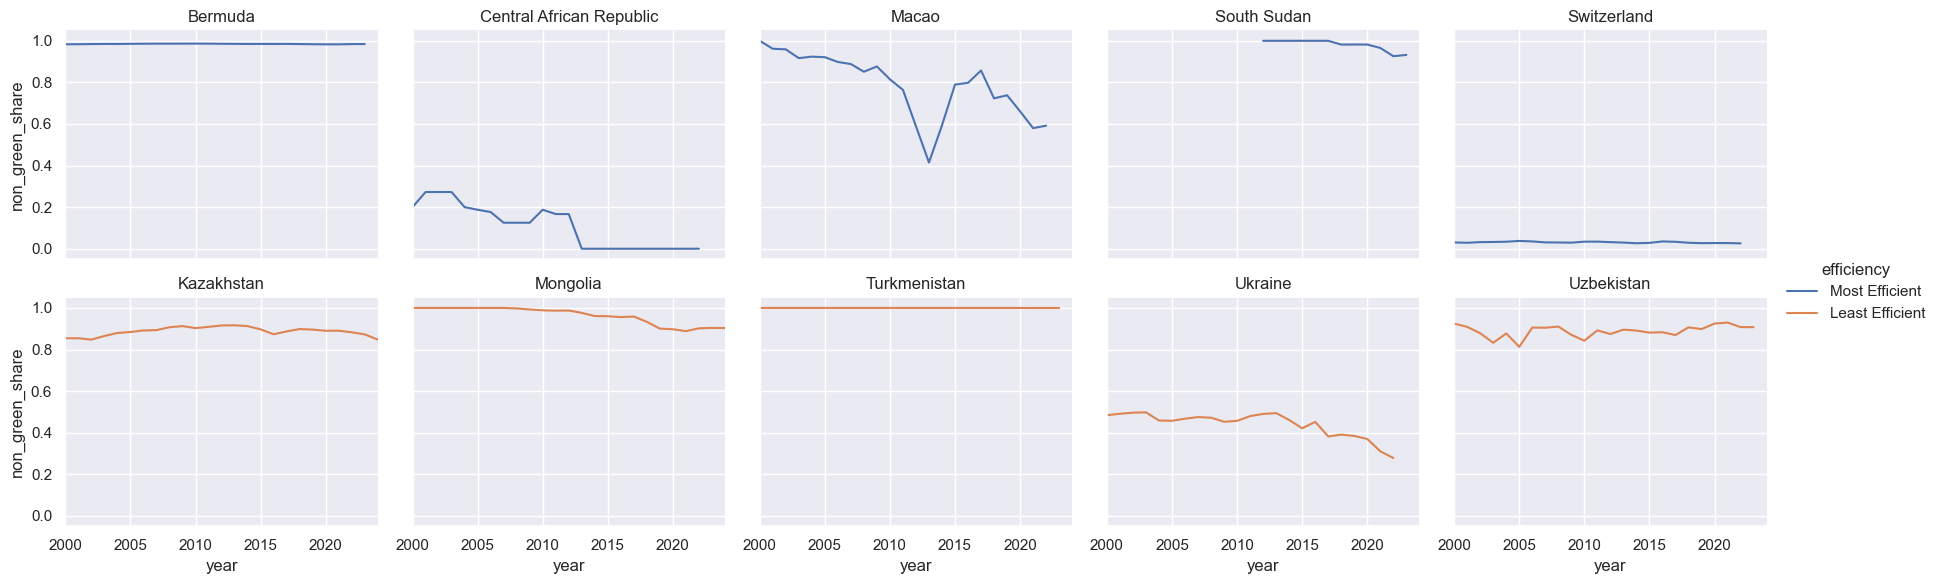

In [23]:
# take the top and least efficient countries
top5_efficient = base_df.groupby('iso_code')['co2_per_gdp'].mean().nsmallest(5).index
top5_inefficient = base_df.groupby('iso_code')['co2_per_gdp'].mean().nlargest(5).index

# change the countries into a plot
countries_to_plot = list(top5_efficient) + list(top5_inefficient)
plot_df = base_df[base_df['iso_code'].isin(countries_to_plot)].copy()

# label each country as efficient or inefficient
plot_df['efficiency'] = plot_df['iso_code'].apply(
    lambda x: 'Most Efficient' if x in top5_efficient else 'Least Efficient'
)

# efficient countries first (top row), then inefficient (bottom row)
efficient_countries = plot_df[plot_df['efficiency'] == 'Most Efficient']['country'].unique()
inefficient_countries = plot_df[plot_df['efficiency'] == 'Least Efficient']['country'].unique()
col_order = list(efficient_countries) + list(inefficient_countries)

# plot
g = sns.relplot(
    data=plot_df,
    x='year', y='non_green_share',
    hue='efficiency',
    col='country', col_wrap=5,
    col_order=col_order,
    kind='line',
    height=3, aspect=1.2,
    facet_kws={'xlim': (2000, 2024)}
)
g.set_titles("{col_name}")

# What electricity production tells us:

Looking at the most and least efficient countries in terms of CO2 per capita we can see a clear trend: 
The more efficient a country is, the less non green energy it produces. 

However, we can also observe some abnormalities: 

**Bermuda** has a 100% non-green share but is deemed efficient. This is mostly due to the incredibly high GDP/GNI. You can say Bermuda makes so much money, that their electricity production does not make a large dent into the CO2 per GDP. <br>
**South Sudan** however, is the opposite - people live in poverty and most do not have electricity at all and get power through burning wood or trash, both not included in the given data. <br>
**Ukraine** might not have the highest share of non green electricity production, however, due to the ongoing war, as well as old Soviet infrastructure, they still struggle with CO2 emmisions. What also plays into this is the declining population, something that drives the CO2 per GPT upwards.

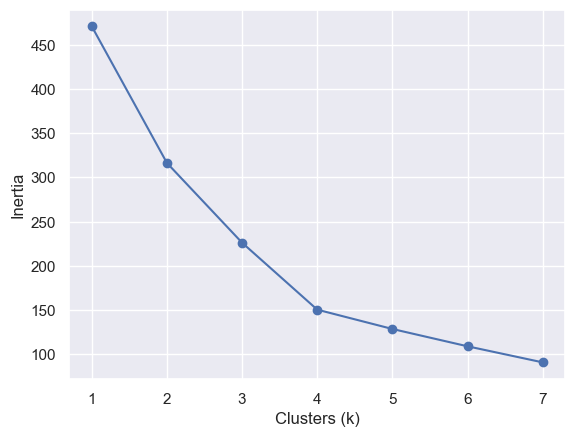

In [24]:
ml_features = ['gdp_per_capita', 'co2_per_gdp', 'non_green_share']
cluster_df = base_df[base_df['year'] == 2023].dropna(subset=ml_features).copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df[ml_features])

inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# We use k = 4 based on ellbow plot
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(scaled_data)

# write the labels back into the original df
cluster_df['cluster'] = cluster_labels

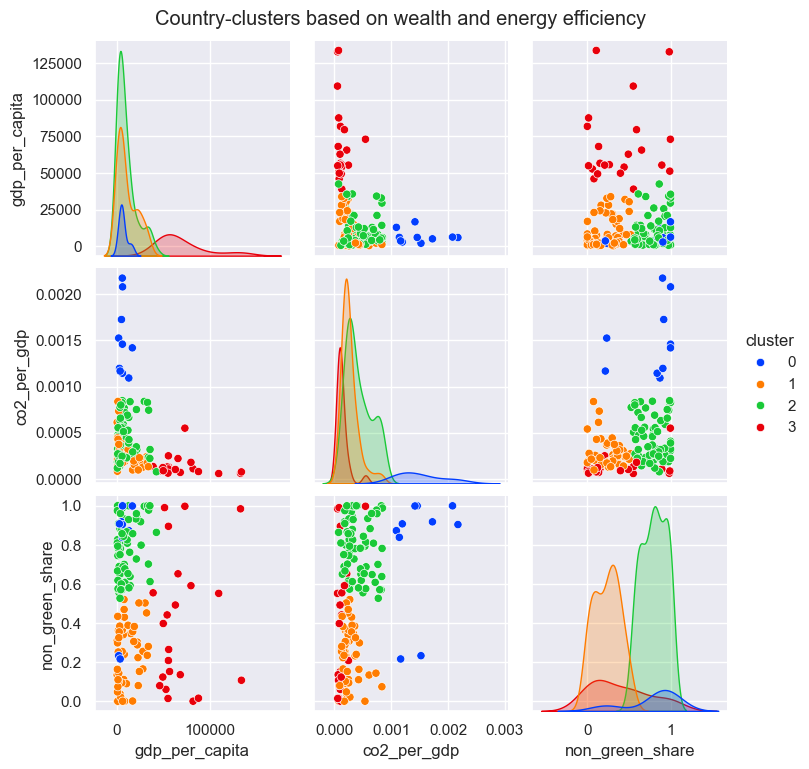

In [32]:
# plot pairplots
sns.pairplot(cluster_df, vars=ml_features, hue='cluster', palette='bright', diag_kind='kde')
plt.suptitle('Country-clusters based on wealth and energy efficiency', y=1.02)
plt.show()

### Interpreting the Pairplot

The pairplot visualizes pairwise relationships between the three clustering features - GDP per capita, CO2 per $M GDP, and non-green electricity share - with each point colored by its KMeans cluster assignment.

- **GDP per capita vs. CO2 per GDP** shows a clear inverse relationship: wealthier countries tend to emit far less CO2 per unit of economic output, reinforcing the efficiency narrative from earlier sections.
- **Non-green share vs. CO2 per GDP** correlates positively - countries that rely heavily on fossil fuels for electricity are also the least carbon-efficient economies overall.
- **GDP per capita vs. non-green share** is more dispersed, suggesting that wealth alone does not guarantee a clean electricity mix (e.g. oil-rich Gulf states are wealthy but fossil-dependent).

The KDE diagonals reveal that most clusters are well-separated along at least one axis, confirming that the four-cluster solution captures meaningful structural differences rather than arbitrary splits.